Global Best Position: -1.3064399293052658, Global Best Value: -7.945823375615247


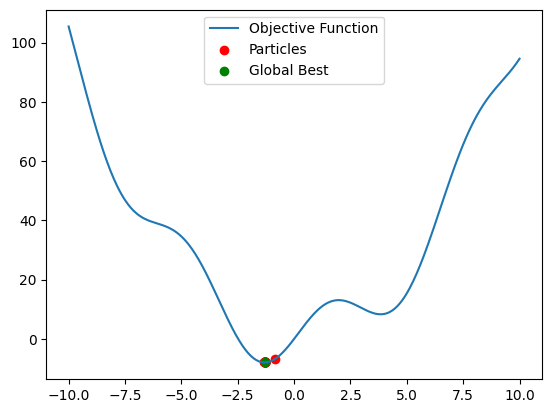

In [7]:
import numpy as np
import matplotlib.pyplot as plt

def f(x):
    return x**2 + 10*np.sin(x)

n_particles = 50
n_iterations = 100
bounds = (-10, 10)
w = 0.7298
c1 = 1.49618
c2 = 1.49618

particles = np.random.uniform(bounds[0], bounds[1], size=(n_particles,))
velocities = np.random.uniform(-1, 1, size=(n_particles,))
personal_best = particles.copy()
global_best = np.inf
global_best_position = None

for _ in range(n_iterations):
    for i in range(n_particles):
        fitness = f(particles[i])
        if fitness < f(personal_best[i]):
            personal_best[i] = particles[i]
        if fitness < global_best:
            global_best = fitness
            global_best_position = particles[i]
    for i in range(n_particles):
        velocities[i] = w * velocities[i] + c1 * np.random.uniform(0, 1) * (personal_best[i] - particles[i]) + c2 * np.random.uniform(0, 1) * (global_best_position - particles[i])
        particles[i] += velocities[i]
        particles[i] = max(bounds[0], min(bounds[1], particles[i]))
print(f"Global Best Position: {global_best_position}, Global Best Value: {global_best}")
x_values = np.linspace(bounds[0], bounds[1], 400)
y_values = f(x_values)
plt.plot(x_values, y_values, label='Objective Function')
plt.scatter(particles, f(particles), label='Particles', color='r')
plt.scatter(global_best_position, global_best, label='Global Best', color='g')
plt.legend()
plt.show()